In [1]:
import tensorflow as tf

I0000 00:00:1783561421.697671   29188 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [10]:
mnist=tf.keras.datasets.mnist


(X_train,y_train),(X_test,y_test)=mnist.load_data()
X_train,X_test=X_train/255.0 , X_test/255.0     #픽셀값이라서 0~1로 스케일링

In [11]:
model=tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(1000,activation="relu"),
    tf.keras.layers.Dense(10,activation="softmax")
])

model.compile(optimizer='adam',
              loss="sparse_categorical_crossentropy",
              metrics=['accuracy']
)


/home/ane/tensorflow/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1000)           │       785,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 795,010 (3.03 MB)

 Trainable params: 795,010 (3.03 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
import time

start_time=time.time()
hist=model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=10,batch_size=100,verbose=1)

print('Fit time',time.time()-start_time)

Epoch 1/10


I0000 00:00:1783561949.162422   29413 service.cc:153] XLA service 0x78a9880322a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783561949.162445   29413 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.5.0; Toolkit: 12.5.0; DNN: 9.23.2)
I0000 00:00:1783561949.176695   29413 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783561949.250588   29413 cuda_dnn.cc:461] Loaded cuDNN version 92302
I0000 00:00:1783561949.255384   29413 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1049__.12


147/600 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8831 - loss: 0.4099

I0000 00:00:1783561951.072915   29413 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9350 - loss: 0.2231 - val_accuracy: 0.9682 - val_loss: 0.1060
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9739 - loss: 0.0877 - val_accuracy: 0.9748 - val_loss: 0.0764
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9838 - loss: 0.0547 - val_accuracy: 0.9763 - val_loss: 0.0728
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9883 - loss: 0.0373 - val_accuracy: 0.9807 - val_loss: 0.0642
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9922 - loss: 0.0253 - val_accuracy: 0.9816 - val_loss: 0.0592
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9945 - loss: 0.0189 - val_accuracy: 0.9818 - val_loss: 0.0602
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9955 - loss: 0.0151 - val_accuracy: 0.9814 - val_loss: 0.0620
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9968 - loss: 0.0111 - val_accuracy: 0.9818 - val_

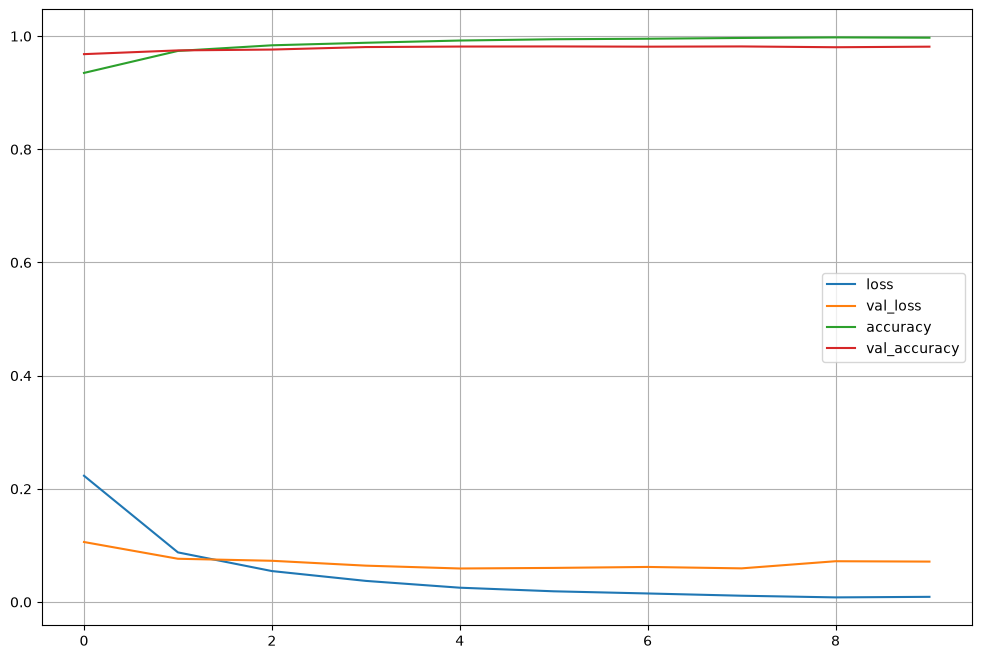

In [16]:
import matplotlib.pyplot as plt


plot_target=['loss','val_loss', 'accuracy','val_accuracy']

plt.figure(figsize=(12,8))

for each in plot_target:
    plt.plot(hist.history[each],label=each)
plt.legend()
plt.grid()
plt.show()

In [19]:
score=model.evaluate(X_test,y_test)
print('Test_loss:',score[0])
print('Test_accuracy',score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9814 - loss: 0.0714
Test_loss: 0.0714113861322403
Test_accuracy 0.9814000129699707


In [26]:
#틀린 거 확인
import numpy as np

predicted_result=model.predict(X_test)
predicted_labels=np.argmax(predicted_result,axis=1)
predicted_labels[:10]



313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 873us/step


array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])

In [27]:
y_test[:10]

array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9], dtype=uint8)

In [28]:
wrong_result=[]

for n in range(0,len(y_test)):
    if predicted_labels[n]!=y_test[n]:
        wrong_result.append(n)
len(wrong_result)

186

In [30]:
import random

samples=random.choices(population=wrong_result,k=16)
samples

[1260,
 6166,
 951,
 5981,
 4078,
 340,
 6598,
 2921,
 1522,
 4500,
 951,
 877,
 4289,
 3005,
 1549,
 5600]

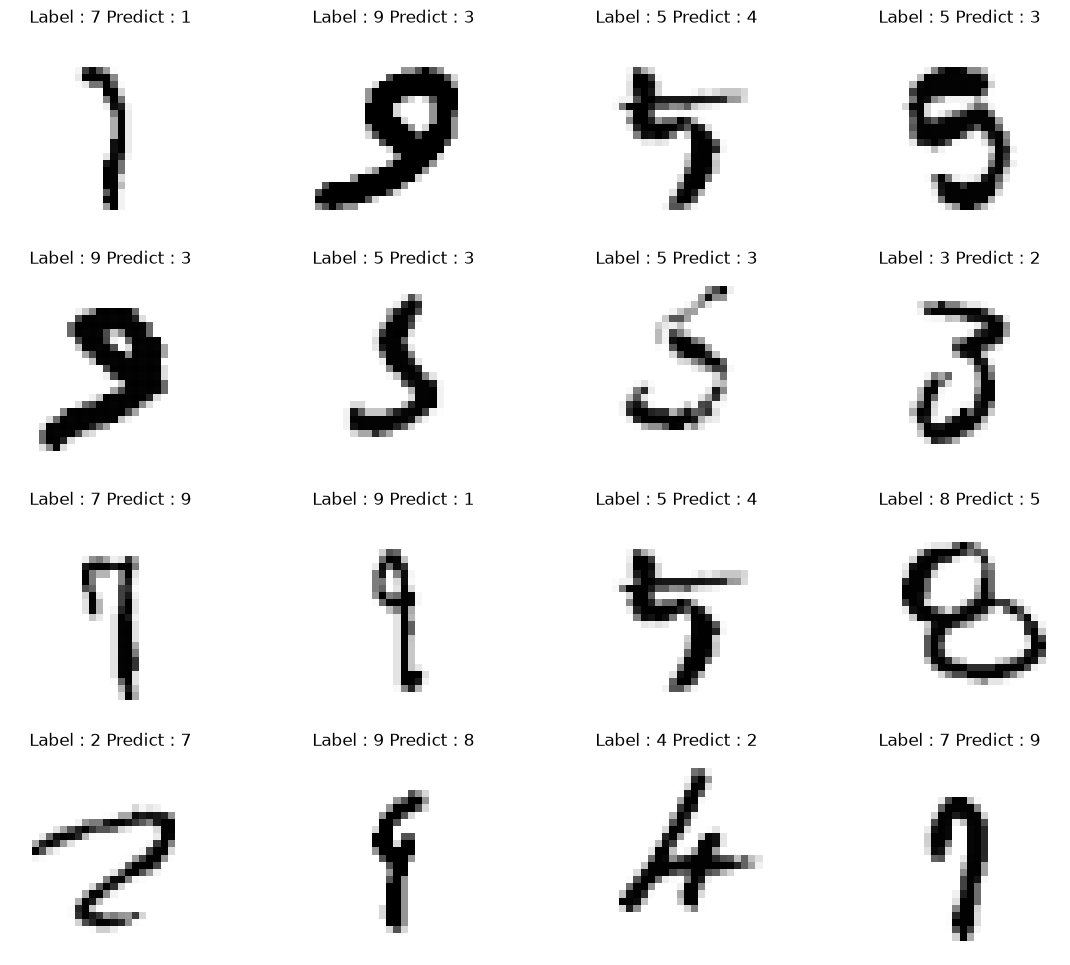

In [32]:
plt.figure(figsize=(14,12))

for idx, n in enumerate(samples):
    plt.subplot(4, 4, idx+1)
    plt.imshow(X_test[n].reshape(28,28), cmap='Greys', interpolation='nearest')
    plt.title('Label : ' + str(y_test[n]) + ' Predict : ' + str(predicted_labels
[n]))
    plt.axis('off')
plt.show()